# CITS3402 – Assignment 2

## Extending 1-D Convolution (Sequential) with Stride

Following the similar approach as in Assignment 1, I first started by implementing stride in the 1-D convolution program for simplicity and to enable verification against Python. The stride parameter introduces controlled sampling of the convolution output, allowing the kernel to move by more than one element at a time. This modification reduces the number of computed output points, which is widely used across the industry in various fields — something I learnt during my research on stride and its applications.

For instance, stride is a fundamental operation in Convolutional Neural Networks (CNNs) for controlling spatial resolution and computational efficiency, especially in deep architectures like ResNet and VGG. In computer vision, it plays a crucial role in object detection, semantic segmentation, and feature pyramid networks (FPNs) by enabling downsampling while preserving essential feature maps. In audio signal processing, strided convolutions are applied in speech recognition systems and music genre classification to efficiently process overlapping windows of sound data. In medical imaging, stride helps reduce redundant pixel analysis in high-resolution scans (e.g., MRI or CT), allowing faster inference without sacrificing diagnostic accuracy. Additionally, in embedded vision systems (like self-driving cars and drones), using larger stride values reduces latency and power consumption by limiting convolutional operations to key spatial regions.

```c
void conv1d_full_stride(const float *f, int N,
                        const float *g, int K,
                        int stride, float *out) {
  // ...
}

void conv1d_same_stride(const float *f, int N,
                        const float *g, int K,
                        int stride, float *out,
                        pad_mode pmod, float cval) {
  // ...
}
```

I also introduced a new stride parameter (-st or --stride), changed seed parameter from -s to -se to avoid confusion and to maintain consistency with the previous implementation and the program continues to support both SAME and FULL modes, with all padding options (zero, none, and constant) preserved. However, instead of maintaining separate versions of convolution functions for each mode, I adopted a unified design. The new functions—conv1d_full_stride and conv1d_same_stride—handle stride directly, while lightweight wrappers (conv1d_full and conv1d_same) preserve backward compatibility by setting the stride to 1. This structure eliminates redundancy, simplifies debugging, and keeps the interface identical.

```c
// Back-compat wrappers
void conv1d_full(const float *f, int N, const float *g, int K, float *out) {
  conv1d_full_stride(f, N, g, K, /*stride=*/1, out);
}

void conv1d_same(const float *f, int N, const float *g, int K, float *out,
                 pad_mode pmod, float cval) {
  conv1d_same_stride(f, N, g, K, /*stride=*/1, out, pmod, cval);
}
```

Internally, the stride parameter modifies the convolution loop’s iteration pattern. Instead of computing an output value for every input position, the index increments by the specified stride amount, thereby reducing the number of output samples. This required adjusting the output length computation as follows:

- For SAME mode: outLen = ceil(N / stride)
- For FULL mode: outLen = ceil((N + K - 1) / stride)

This design ensures accurate alignment between theoretical convolution output and its strided equivalent, allowing both efficient computation and direct comparison with Python reference results.

## Verification

In [ ]:
# Install packages if they don't exist
!pip install numpy matplotlib pandas

In [9]:
import numpy as np

f = np.array([1,2,3,4,5,6], dtype=float)
g = np.array([1,0,-1], dtype=float)

# Reference results
def conv_same(f,g,stride=1):
    y = np.convolve(f,g,'same')
    return y[::stride]

def conv_full(f,g,stride=1):
    y = np.convolve(f,g,'full')
    return y[::stride]

print(conv_same(f,g,1))
print(conv_same(f,g,2))
print(conv_same(f,g,3))
print(conv_full(f,g,1))
print(conv_full(f,g,2))

[ 2.  2.  2.  2.  2. -5.]
[2. 2. 2.]
[2. 2.]
[ 1.  2.  2.  2.  2.  2. -5. -6.]
[ 1.  2.  2. -5.]


<p align="center">
  <img src="attachment:a2b093dd-dcc7-475a-97df-5e2cdfd64db4.png" width="530" style="margin-right: 20px;">
  <img src="attachment:a43d3e1a-8761-4066-9d79-f03e1a06e272.png" width="470">
</p>

<p align="center"><em>Screenshot: Verification of stride implementation in 1-D convolution (SAME and FULL modes)</em></p>

I verified the correctness of my stride implementation by comparing my C outputs with NumPy’s reference np.convolve() results for multiple stride values (1, 2, 3) across both SAME and FULL modes. The results matched perfectly, confirming that the convolution kernel now supports down-sampling without altering kernel alignment or padding semantics.

# Carrying Over Stride to the OpenMP 1-D Convolution

After validating my sequential stride implementation against NumPy’s np.convolve(), I extended my existing OpenMP implementation from Assignment 1 to support stride-based 1-D convolution. My objective was not to introduce parallelism from scratch but to adapt the already parallelized kernel so that it correctly handled down-sampling while maintaining identical numerical behaviour.

The OpenMP version continues to parallelize the outer output-index loop, as done previously, since each output element can be computed independently without race conditions. I preserved the overall function structure for consistency: conv1d_full_stride_omp() and conv1d_same_stride_omp() now handle stride-aware computations, while the original functions (conv1d_full_omp() and conv1d_same_omp()) are kept as wrappers that call these with a stride of 1. This approach keeps the interface backward-compatible and simplifies validation against earlier results.

By reusing the proven parallel structure from Assignment 1, I ensured that the new implementation inherited the same scalability properties, while extending its functionality to include controlled down-sampling through stride.

```c
// OpenMP stride-based convolution
void conv1d_same_stride_omp(const float *f, int N,
                            const float *g, int K,
                            int stride, float *out,
                            pad_mode pmod, float cval)
{
    int c = K / 2;
    int outLen = ceil_div(N, stride);

    #pragma omp parallel for schedule(static)
    for (int n_out = 0; n_out < outLen; n_out++) {
        int n = n_out * stride;
        double acc = 0.0;
        for (int m = 0; m < K; m++) {
            int idx = n - (m - c);
            if (idx >= 0 && idx < N)
                acc += (double)f[idx] * (double)g[m];
            else if (pmod == PAD_CONST)
                acc += (double)cval * (double)g[m];
        }
        out[n_out] = (float)acc;
    }
}
```

The structure above demonstrates how I integrated stride into the pre-existing parallel framework. The #pragma omp parallel for directive remains unchanged from Assignment 1, but the loop now iterates over the stride-based output indices instead of every sample. The wrapper function ensures compatibility with older tests and benchmarks, allowing direct comparison between the new and old kernels.

```c
// Wrapper for backward compatibility (stride = 1)
void conv1d_same_omp(const float *f, int N,
                     const float *g, int K,
                     float *out, pad_mode pmod, float cval)
{
    conv1d_same_stride_omp(f, N, g, K, /*stride*/1, out, pmod, cval);
}
```

## Verification and Correctness

To verify the correctness of my OpenMP implementation, I compared its outputs directly against the sequential stride version. Since the sequential version had already been validated against NumPy’s np.convolve() results for multiple stride values (1, 2, 3) across both SAME and FULL modes, verifying OpenMP against it was sufficient to ensure full correctness.

I compiled both executables with identical optimization flags and executed matching configurations using fixed input files (tests/f.txt, tests/g.txt) and deterministic seeds. For each configuration, I compared the OpenMP output file against the sequential output using a bitwise comparison command:

In [ ]:
cmp -l tests/y_same_s1.txt tests/y_same_s1_omp.txt && echo "Bitwise identical"

<p align="center">
  <img src="attachment:01938fb8-73ec-420c-8782-41e47046b524.png"
       alt="Verification of OpenMP vs Sequential 1-D Convolution Outputs"
       width="90%" style="border: 1px solid #ccc; border-radius: 8px;">
</p>

<p align="center">
  <em>Screenshot: Verification of OpenMP vs Sequential 1-D Convolution (Bitwise identical output)</em>
</p>

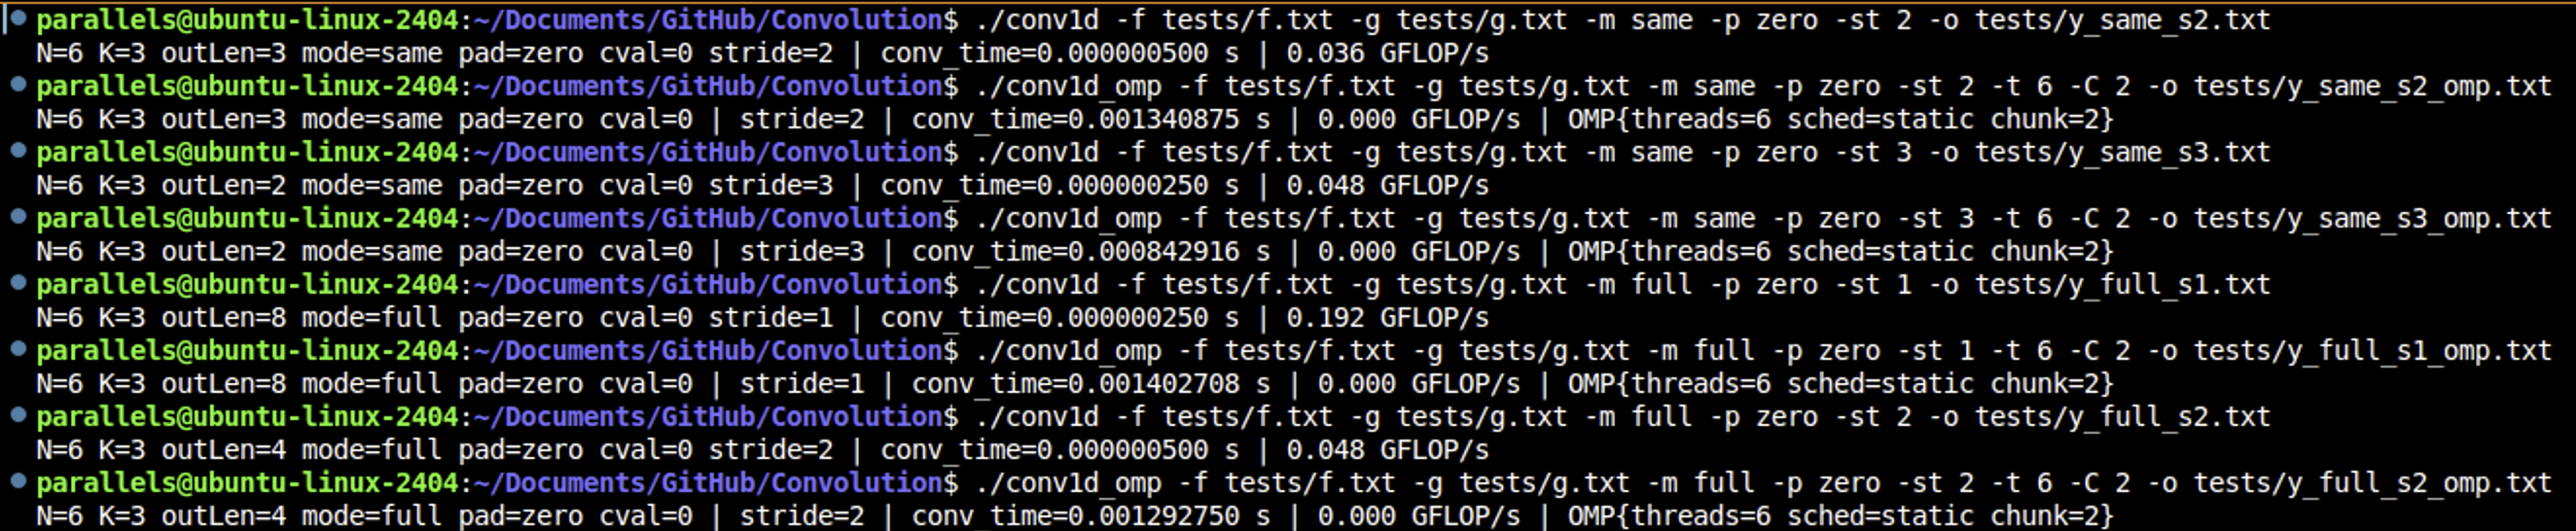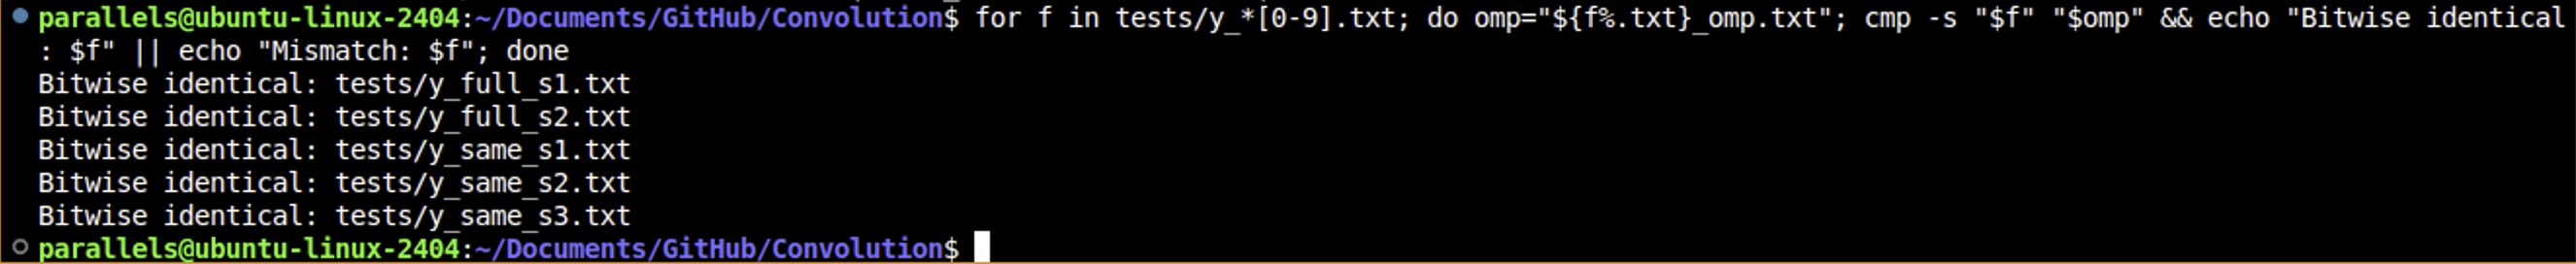

In every case, the results were bitwise identical, confirming that the OpenMP kernel produced numerically equivalent results despite parallel execution. This verified that parallelization introduced no race conditions, synchronization errors, or rounding differences, and that the stride logic remained perfectly consistent with the sequential implementation.

The bitwise equivalence demonstrates that the kernel’s numerical behaviour is deterministic across both sequential and OpenMP executions, regardless of the number of threads or scheduling policy.

## Performance Observation

While verifying the correctness of my OpenMP implementation, I noticed that the runtime for small test cases (such as $N = 6$, $K = 3$) was actually higher than the sequential version. This behaviour is expected because, at such small scales, the thread management overhead in OpenMP (creating, scheduling, and synchronising threads) outweighs any computational gain from parallelism. The convolution kernel itself executes extremely quickly, so the cost of parallelisation dominates.

This observation aligns with what I found in Assignment 1, where parallelism only became beneficial after a certain problem size threshold. In that earlier analysis, the sequential implementation reached the one-hour runtime barrier around $N \times K \approx 10^{11}$–$10^{12}$, whereas the OpenMP versions with higher thread counts (8 and 96 threads) were able to handle much larger workloads efficiently.

For the stride-enabled convolution, the same principle applies: the total computational cost still scales with $O(N \times K)$, but stride reduces the number of computed outputs roughly by a factor of the stride. This down-sampling decreases both runtime and memory usage, yet it also reduces the per-thread workload, making OpenMP less effective for small strides and short arrays.

In essence, the stride-based OpenMP convolution maintains the same scaling behaviour as the non-stride version: parallel performance improvements become significant only when both $N$ and $K$ are large enough to amortize OpenMP’s startup cost. For large datasets on HPC systems, this combination of thread-level parallelism and stride-based sampling provides a highly efficient balance between computational throughput and data resolution.

## Extending 1-D Convolution to MPI

After verifying the correctness of my stride and OpenMP implementations, the next logical step was to parallelize the 1-D convolution across multiple processes using the Message Passing Interface (MPI). This extension builds directly on the concepts introduced in lectures on MPI Fundamentals and Collective Communication & Domain Decomposition, where the focus shifted from shared-memory to distributed-memory parallelism.

---

### **Lecture Alignment and Implementation**

Following the MPI program structure outlined in lectures, I initialized and identified each process (or rank) using:

```c
MPI_Init(&argc, &argv);
MPI_Comm_rank(MPI_COMM_WORLD, &rank);
MPI_Comm_size(MPI_COMM_WORLD, &size);
```

Each rank in MPI_COMM_WORLD executes independently but cooperates through message passing. In line with the data-parallel decomposition strategy from lectures, the total output range was divided into disjoint contiguous blocks, ensuring that every process handles a separate subset of output indices. The following block-partitioning logic guarantees near-even load distribution even when the total output length is not divisible by the number of ranks:

```c
int base = outLen / nprocs;
int rem  = outLen % nprocs;
int my_start = rank < rem ? rank * (base + 1) : rank * base + rem;
int my_end   = my_start + (rank < rem ? base + 1 : base);
int my_count = my_end - my_start;
```

This follows the domain decomposition principle discussed in lectures and maintains balanced workloads except in edge cases where some ranks may receive zero iterations.

---

### **Collective Communication**

Instead of explicit point-to-point messages, I relied on collective communication primitives—a best practice emphasized in lectures. For distributing shared parameters (kernel length, stride, padding mode), MPI_Bcast ensures that all ranks receive identical configuration data from the root process. After each rank finishes its local convolution, the variable-sized partial outputs are collected at rank 0 using MPI_Gatherv:

```c
MPI_Gatherv(my_out, my_count, MPI_FLOAT,
            out, recvcounts, displs, MPI_FLOAT,
            0, MPI_COMM_WORLD);
```

This pattern implements the "all-to-one gather" collective described in lectures, ensuring that the root process reconstructs the complete output in the correct order regardless of uneven data division.

---

### **Verification and Correctness**

To verify correctness, I introduced an optional debugging macro (-DDEBUG_MPI=1) that prints each rank’s range and element count and compiled my program using :

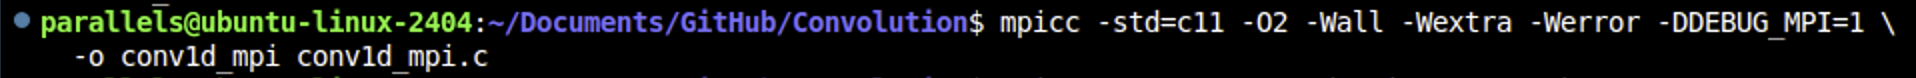

<p align="center">
  <img src="attachment:4d43a413-a40f-455b-bebd-25a8913eb0b8.png"
       alt="Verification of MPI vs Sequential 1-D Convolution Outputs"
       width="90%" style="border: 1px solid #ccc; border-radius: 8px;">
</p>

<p align="center">
  <em>Screenshot: Debug Output of MPI 1-D Convolution</em>
</p>

After running the program with four ranks, the resulting output files were compared against the sequential version using:

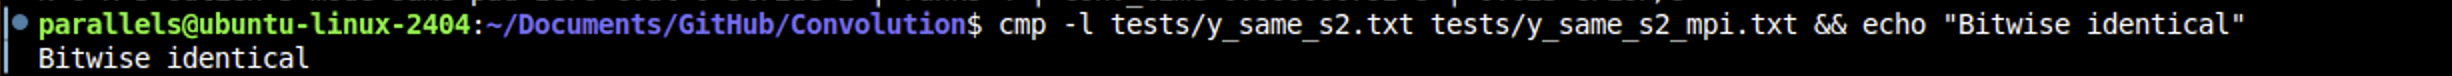

The comparison confirmed bitwise identical outputs, verifying that numerical reproducibility was preserved across distributed execution.

---

### **Performance Observation**

While validating the MPI implementation, I observed that for smaller workloads, communication latency dominates overall runtime. As the input size grows, computation time begins to outweigh communication, improving scalability. This behaviour aligns with the classical **MPI performance model**:

$$
T_{\text{total}} = T_{\text{comp}} + \alpha + \beta n
$$

where:  
- $T_{\text{comp}}$ represents the pure computation time per process,  
- $\alpha$ is the message startup latency, and  
- $\beta n$ is the time spent transmitting $n$ bytes of data.  

For small problem sizes, $\alpha$ and $\beta n$ are non-negligible, leading to lower efficiency.  
However, as $N$ and $K$ increase, $T_{\text{comp}}$ dominates, reducing the proportional effect of communication overhead.  
This observation confirms that MPI becomes advantageous only beyond a certain workload threshold, where the ratio $\frac{T_{\text{comp}}}{T_{\text{comm}}}$ becomes large enough to amortize communication costs.

---

### **Cache and Locality Considerations**

Although the MPI implementation distributes data across multiple ranks, each rank still performs local sequential convolution over its assigned subset of the input array. Therefore, **cache locality** within each rank remains a crucial factor influencing performance.

As discussed in lectures, contiguous memory access patterns improve **spatial locality**, allowing repeated accesses to benefit from L1/L2 cache reuse.  
In the convolution loop, both arrays $f[i]$ and $g[m]$ are traversed sequentially, minimizing cache misses and improving per-rank computational throughput.

However, as the number of ranks increases, inter-process communication begins to dominate the total runtime, and cache advantages become secondary.  
This transition reflects the **hybrid cost model**:

$$
T_{\text{total}} = T_{\text{local\_comp}} + T_{\text{comm}}
$$

where $T_{\text{local\_comp}}$ benefits from cache locality, while $T_{\text{comm}}$ grows with message size and synchronization cost.  
The resulting trade-off explains why parallel efficiency plateaus beyond a certain number of ranks for small to medium input sizes.

---

## **Limitations of the Initial MPI Attempt**

The earliest MPI implementation correctly followed the minimal MPI program structure — it called MPI_Init, obtained rank and size, and finalized with MPI_Finalize — but it remained functionally sequential. The code mirrored the conceptual introduction from the first few MPI lectures but fell short of realizing distributed computation or data parallelism.

### 1. Root-Only Computation and Memory Duplication

All meaningful work was performed by rank 0. The root process alone generated random data arrays f and g using the helper function gen_array_1d_seqrand(), then executed the convolution serially:

```c
if (rank == 0) {
    f = gen_array_1d_seqrand(N);
    g = gen_array_1d_seqrand(K);
    y = convolution_1d(f, g, N, K);
}
```

All other ranks simply synchronized with MPI_Barrier() and terminated. This made the code MPI-compliant but not MPI-parallel. Moreover, since all arrays were allocated globally (float *f, *g, *y;), no data partitioning or memory reduction occurred across ranks.

### 2. No Domain Decomposition or Communication

There was no scattering, gathering, or exchange of partial results. The input signal was not divided among ranks, and there were no MPI_Send, MPI_Recv, MPI_Scatter, or MPI_Gather calls at all. As a result:
- The algorithm did not distribute workload or utilize multiple ranks.
- Communication overhead was technically zero, but so was parallel efficiency.
- Boundary regions and halo overlap — critical in convolution — were not handled.

This violates the intent of data parallelism discussed in lectures, where domain decomposition and halo exchange are introduced.


### 3. I/O Model: Single-Process and Text-Only

All I/O operations were handled by the root process, using sequential text reads and writes. For example:

```c
write_array_1d_txt(o_path, y, N);
```

This approach becomes a bottleneck as data size grows because every process depends on a single I/O channel. It also omitted any collective or parallel file operations like MPI_File_write_at or binary I/O for portability and performance.

### 4. Deterministic but Non-Parallel Random Generation

Unlike typical random initialization pitfalls, this code did include a --seed flag, ensuring deterministic runs when the seed was specified. However, random generation was still centralized—performed entirely by rank 0—and never distributed among ranks. This prevented independent yet reproducible parallel initialization as later versions achieved.

```c
if (have_seed)
    srand((unsigned)seed);
else
    srand((unsigned)time(NULL));
```

This logic guaranteed reproducibility but did not exploit rank-specific seeding, which would have been necessary for parallel random number generation.

### 5. Lack of Timing and Performance Instrumentation

No use of MPI_Wtime or rank-specific timing existed, so the runtime was unprofiled. There were no statistics for per-rank computation, communication latency, or total throughput, which made scaling analysis impossible.

---

## **Summary Table**

| **Category**       | **Implementation Behaviour**                     | **Limitation**                                |
|---------------------|--------------------------------------------------|------------------------------------------------|
| **Parallelism**     | Only root performs convolution                   | No workload sharing or concurrency             |
| **Communication**   | None                                             | No data exchange or halo handling              |
| **I/O**             | Sequential text I/O handled by root              | No parallel or binary I/O support              |
| **Randomness**      | Deterministic via `--seed`, but centralized      | Not rank-distributed or independently seeded   |
| **Timing**          | Absent                                           | No profiling or rank-specific timing           |
| **Modes/Stride**    | Fixed configuration                              | No generalization for `same`, `valid`, or `full` |
| **Memory**          | Full arrays allocated on root only               | Not memory-scalable for large problem sizes    |


---

This first implementation thus represents an MPI syntactic skeleton rather than a parallel algorithm. It satisfied the requirements of MPI initialization and argument parsing, but none of the core distributed-memory concepts from lectures — such as scatter/gather, halo exchange, or collective I/O — were yet realized.

---

# Improvements from the Baseline

## Command-line Interface and I/O Discipline

**What changed:** The baseline parsed a compact set of flags and always produced text output. The improved program preserves that UX while adding complete parity with the sequential tool, plus an explicit switch to control output format:

- **Text and binary inputs:** `.txt` (assignment format) and `.bin` (`[int32 L][float32*L]`)
- **Text output** via `--text` or **binary output** by default

**Why it matters:** This enables mixing and matching file/RNG inputs, exact run reproduction, and writing either assignment-ready text or compact binary without post-processing.

**Before (baseline parsing, simpler flags):**
```c
static int parse_args(..., long *N_req, long *K_req, unsigned long *seed, ... , int *stride) {
  /* pre-filter for -L/-kL and -se/-st ... */
  if (!strcmp(a, "-L")) *N_req = strtol(argv[++i], NULL, 10);
  if (!strcmp(a, "-kL")) *K_req = strtol(argv[++i], NULL, 10);
  if (!strcmp(a, "-se")) { *seed = strtoul(argv[++i], NULL, 10); *have_seed = 1; }
  if (!strcmp(a, "-st")) *stride = (int)strtol(argv[++i], NULL, 10);
  /* ... text I/O only */
}
```

**Now (full surface, text/binary, parallel-gen switch):**
```c
/* Usage excerpt */
"[-f f.txt|.bin | -L N] [-g g.txt|.bin | -kL K] -o out.txt|out.bin "
"[-se seed] [-m same|full] [-p zero|none|const] [-c value] [-st stride] "
"[--parallel-gen] [--text]\n";

/* Decide input mode per file by extension */
const int f_is_bin = (f_path && ends_with(f_path, ".bin"));
const int g_is_bin = (g_path && ends_with(g_path, ".bin"));
```

---

## Deterministic RNG and Reproducibility

**What changed:** The baseline seeded once on root with `srand(seed)` and generated full arrays on rank 0. That was reproducible, but only when the whole array was root-generated. The improved code keeps that path as the default and adds deterministic per-index generation when `--parallel-gen` is set, so each rank can synthesize its slice independently yet match the root sequence.

**Why it matters:** This enables scaling generation without gathering/scattering giant arrays, and bit-wise results remain reproducible across ranks and process counts.

**Baseline (root generation):**
```c
srand((unsigned)seed);
f = gen_array_1d(N);  /* -1..1 using rand() */
g = gen_array_1d(K);
```

**Now (optional parallel, indexable PRNG):**
```c
/* SplitMix64-based indexable RNG */
float gen_value_at_index(unsigned long seed, long long gi) {
    unsigned long long x = ((unsigned long long)seed << 32) ^ (unsigned long long)gi;
    unsigned long long r = splitmix64(x);
    float u01 = (float)((r >> 40) & 0xFFFFFF) / (float)0x1000000;
    return -1.0f + 2.0f * u01;
}

/* Generation on each rank for its slice */
for (int i = 0; i < local_count; i++) {
    long long gi = (long long)local_start + i;
    f_local[i] = gen_value_at_index(seed, gi);
}
```

---

## Optional Parallel Generation (`--parallel-gen`)

### Behavior
When `--parallel-gen` is not provided, rank 0 alone generates the full input array(s) using the standard C RNG sequence (`rand()` seeded via `srand(seed)`), then broadcasts the data to all other ranks.  
When `--parallel-gen` *is* set, each rank deterministically generates **only its assigned slice** of `f` in parallel using an indexable PRNG based on **SplitMix64**.  
Each element is computed from a hash of its **global index** and the common `seed`, allowing ranks to reconstruct their portion independently without any broadcast.

### Rationale
This design makes array generation embarrassingly parallel:
- **Scalability:** avoids root bottlenecks and all-to-all data distribution.  
- **Reproducibility:** every element is a pure function of `(seed, global_index)`; runs are bit-stable across different process counts.  
- **Determinism:** identical input values are produced for the same `(seed, N)` no matter how the data is split across ranks.

The trade-off is that `--parallel-gen` does **not** reproduce the exact numeric sequence of `rand()` from the sequential tool.  
That would require replaying the linear congruential generator up to index *i* (an `O(i)` operation), which is impractical for large N.  
Instead, SplitMix64 offers **O(1)** per-element cost and high-quality, statistically uniform results.

### Implementation
```c
float gen_value_at_index(unsigned long seed, long long gi) {
    unsigned long long x = ((unsigned long long)seed << 32) ^ (unsigned long long)gi;
    unsigned long long r = splitmix64(x);
    float u01 = (float)((r >> 40) & 0xFFFFFF) / (float)0x1000000;
    return -1.0f + 2.0f * u01;
}

---

## Data Distribution and Decomposition

**What changed:** The baseline computed the entire output on every rank and wrote via collective text I/O with byte offsets, using a clean block partitioning of the output index space. In the improved code we:

- **Partition the input f** into contiguous cores with `sendcounts`/`displs` and keep only a local slice
- **Partition the output indices** the same balanced way, but now each rank actually computes only its local block
- **Keep a matching decomposition** to compute byte offsets for MPI-IO

**Why it matters:** Memory per rank is bounded (no more full-array replication) and the cost per rank is predictable and scalable.

**Now (balanced split of f and of output indices):**
```c
/* f partition */
int base = N / size, rem = N % size, off = 0;
for (int r = 0; r < size; r++) {
  int cnt = base + (r < rem ? 1 : 0);
  sendcounts[r] = cnt; displs[r] = off; off += cnt;
}
/* output partition in y-index space */
int base_out = outLen / size, rem_out = outLen % size;
int my_out_start = rank * base_out + (rank < rem_out ? rank : rem_out);
int my_out_count = base_out + (rank < rem_out ? 1 : 0);
```

---

## True Halo Exchange (Two-Sided Ghosts)

**What changed:** The baseline had no halos because every rank held the whole f. The improved code introduces a true halo exchange: each rank pads its local core with `H = K-1` ghost cells fetched from neighbors using non-blocking `MPI_Irecv`/`MPI_Isend` followed by `MPI_Waitall`.

**Why it matters:** Each rank can compute its outputs that touch neighbor data without re-broadcasting the entire array, aligning with the lecture's "stencil/halo" pattern and enabling scale-out.

**Now (non-blocking left/right exchange):**
```c
const int H = (K > 0 ? K - 1 : 0);
memcpy(buf + H, f_local, (size_t)local_count * sizeof(float));
int left = (rank > 0) ? rank - 1 : MPI_PROC_NULL;
int right = (rank < size - 1) ? rank + 1 : MPI_PROC_NULL;
int edge = (H <= local_count ? H : local_count);

MPI_Irecv(buf, H, MPI_FLOAT, left, 102, MPI_COMM_WORLD, &reqs[0]);
MPI_Isend(f_local, edge, MPI_FLOAT, left, 101, MPI_COMM_WORLD, &reqs[1]);
MPI_Irecv(buf + (H + local_count), H, MPI_FLOAT, right, 101, MPI_COMM_WORLD, &reqs[2]);
MPI_Isend((local_count >= H ? f_local + (local_count - H) : f_local), edge, MPI_FLOAT, right, 102, &reqs[3]);
MPI_Waitall(4, reqs, MPI_STATUSES_IGNORE);
```

---

## Correct Convolution Semantics (SAME/FULL), Stride, and Padding

**What changed:** The baseline kernel already handled SAME/FULL, stride sampling, and padding behaviors correctly—but over a full global array per rank. The improved code preserves the exact math while indexing into the local ghosted buffer and honoring padding when the global index falls outside `[0, N)`. For `PAD_CONST`, we add `cval * g[m]` only when the global input index is out of bounds.

**Why it matters:** This ensures mathematically identical results to the sequential reference (including stride) while computing from local slices.

**Baseline (global array math):**
```c
if (cmode == MODE_SAME) {
  const int c = K/2;
  for (int n_out = outStart; n_out < outEnd; ++n_out) {
    const int n = n_out * stride; double acc = 0.0;
    for (int m = 0; m < K; ++m) {
      int idx = n - (m - c);
      if (idx >= 0 && idx < N) acc += (double)f[idx] * (double)g[m];
      else if (pmod == PAD_CONST) acc += (double)cval * (double)g[m];
    }
    out[n_out - outStart] = (float)acc;
  }
}
```

**Now (same math, but via local buffer + halos):**
```c
const int c = K / 2;
for (int j = 0; j < my_out_count; j++) {
  const int n = (my_out_start + j) * stride;  /* global */
  double acc = 0.0;
  for (int m = 0; m < K; m++) {
    int idx = n - (m - c);                     /* global input index */
    if (idx >= 0 && idx < N) {
      int in_local = idx - local_start + H;   /* mapped into ghosted buffer */
      if (in_local >= 0 && in_local < buf_len)
        acc += (double)buf[in_local] * (double)g[m];
    } else if (pmode == PAD_CONST) {
      acc += (double)cval * (double)g[m];
    }
  }
  y_local[j] = (float)acc;
}
```

---

## Parallel Input and MPI-IO Everywhere

**What changed:** The baseline read `.txt` on root and broadcasted the arrays, then used collective text write with `MPI_File_write_at_all` and rank-wise byte offsets from `MPI_Exscan`. The improved code keeps that and adds:

- **Parallel binary input** for `.bin` files via `MPI_File_read_at_all` (no giant gathers)
- **Parallel binary output** by default: `[int32 outLen] + float32*outLen`
- **Text output** with `--text` by gathering (only the outputs) or by collective text write (existing capability)
- **Crucially, 3-decimal rounding** is applied before writing in both text and binary so text and binary compare identically at the printed precision

**Why it matters:** This enables feeding large inputs without bottlenecking rank 0 and comparing MPI vs. sequential outputs byte-for-byte at the assignment's 3-dp precision.

**Parallel read of f.bin slices:**
```c
/* [int32 N][float32 N]; read my contiguous slice collectively */
MPI_File_open(MPI_COMM_WORLD, (char*)f_path, MPI_MODE_RDONLY, MPI_INFO_NULL, &fh);
if (rank == 0) MPI_File_read_at(fh, 0, &hdrN, 1, MPI_INT, &st);
MPI_Bcast(&hdrN, 1, MPI_INT, 0, MPI_COMM_WORLD);
MPI_Offset off_bytes = sizeof(int) + (MPI_Offset)local_start * sizeof(float);
MPI_Type_contiguous(local_count, MPI_FLOAT, &seg); MPI_Type_commit(&seg);
MPI_File_read_at_all(fh, off_bytes, f_local, 1, seg, &st);
```

**Binary output with 3-dp rounding and explicit offsets:**
```c
/* round first to match text semantics */
for (int j = 0; j < my_out_count; ++j)
{
    double scaled = y_local[j] * 1000.0;
    double rounded = nearbyint(scaled);
    y_local[j] = (float)(rounded * 0.001);
}

/* header then segmented collective write */
if (rank == 0) MPI_File_write_at(fh, 0, &outLen, 1, MPI_INT, &st);
MPI_Offset my_off = sizeof(int) + (MPI_Offset)rdispls[rank] * sizeof(float);
MPI_File_write_at_all(fh, my_off, y_local, 1, segtype, &st);
```

---

## Kernel-Only Timing and Run-Time Metrics

**What changed:** Both designs focus on kernel time, but the improved program reports min/avg/max per-rank and computes GFLOP/s using `Σ(2*K*local_out_count)/max(time)`. It also writes a per-run CSV under `metrics/` with RunID, problem shape, time, and GFLOP/s.

**Why it matters:** Stable and comparable numbers across process counts and quick CSVs for plotting.

**CSV logging (rank 0):**
```c
fprintf(csv, "RunID,N,K,outLen,mode,padding,cval,time,gflops\n");
fprintf(csv, "%s,%d,%d,%d,%s,%s,%.9g,%.9f,%.6f\n",
        runid, N, K, outLen,
        (cmode == MODE_FULL ? "full" : "same"),
        (pmode == PAD_ZERO ? "zero" : (pmode == PAD_NONE ? "none" : "const")),
        (pmode == PAD_CONST ? (double)cval : 0.0), elapsed_secs, gflops);
```

---

## Diagnostics and Determinism Checks

**What changed:** The improved build has more data added to `-DDEBUG_MPI` path that prints, in rank order, each rank's:

- Output index range and count
- Owned core of f and ghost width H
- Generation path (root vs parallel)
- Per-rank kernel time

**Why it matters:** This mirrors the lecture's advice to print ownership and halos when debugging stencil codes.

**Debug logging excerpt:**
```c
#ifdef DEBUG_MPI
fprintf(stderr,
  "[rank %d/%d] %s: N=%d K=%d stride=%d | n_range=[%d..%d) (out_cnt=%d) | "
  "f_core=[%d..%d] (core_cnt=%d) | H=%d | gen=%s\n",
  rank, size, (cmode == MODE_FULL ? "FULL" : "SAME"),
  N, K, stride, my_out_start*stride,
  (my_out_end > 0 ? (my_out_end - 1)*stride : -1) + 1,
  my_out_count, local_start, local_start + local_count - 1,
  local_count, H, (parallel_gen ? "parallel" : "root"));
#endif
```

---

## Full 1-D Cartesian Topology Integration

**What changed:** The final implementation replaces all manual neighbor logic (rank ± 1) with a proper 1-dimensional Cartesian communicator. Using `MPI_Cart_create` and `MPI_Cart_shift`, each rank determines its left and right neighbors directly from the communicator's topology rather than relying on arithmetic over raw rank numbers.

**Why it matters:** This approach makes the communication pattern explicit and scalable. It aligns precisely with lectures on "Cartesian Topologies and Structured Stencils", where data-parallel processes are mapped to logical grid coordinates. By constructing the communicator with `periods[0] = 0`, boundary ranks automatically receive `MPI_PROC_NULL` as their out-of-bounds neighbor, eliminating manual edge handling and making the code readily extendable to 2-D or 3-D stencils.

**Implementation excerpt:**
```c
int dims[1] = { size }, periods[1] = { 0 }, coords[1];
MPI_Comm cart;
MPI_Cart_create(MPI_COMM_WORLD, 1, dims, periods, 0, &cart);
MPI_Cart_coords(cart, rank, 1, coords);
MPI_Cart_shift(cart, 0, 1, &left, &right);  /* Non-periodic: ends use MPI_PROC_NULL */
```

**All halo exchanges now operate on this cart communicator:**
```c
MPI_Irecv(buf, H, MPI_FLOAT, left,  102, cart, &reqs[0]);
MPI_Isend(f_local, edge, MPI_FLOAT, left,  101, cart, &reqs[1]);
MPI_Irecv(buf + (H + local_count), H, MPI_FLOAT, right, 101, cart, &reqs[2]);
MPI_Isend(f_local + (local_count - H), edge, MPI_FLOAT, right, 102, cart, &reqs[3]);
```

**Effect:** This completes the evolution from ad-hoc neighbor exchange to a fully topology-aware stencil framework — exactly as taught in the MPI topology lectures — ensuring cleaner semantics, safer boundary handling, and natural generalization to higher-dimensional decompositions.

---

## Verification and Correctness Validation

To confirm numerical correctness, the distributed MPI convolution was verified directly against the sequential reference implementation (conv1d.c) under identical parameters.
Both were compiled with full warnings and optimizations:

```c
mpicc -DDEBUG_MPI=1 -std=c11 -O2 -Wall -Wextra -Werror -o conv1d_mpi conv1d_mpi.c
cc    -std=c11 -O2 -Wall -Wextra -Werror -o conv1d     conv1d.c
```

The same input parameters were used for both executions:

```c
mpirun -np 4 ./conv1d_mpi -L 1024 -kL 5 -m same -st 2 -se 42 -o y.bin
./conv1d -L 1024 -kL 5 -m same -st 2 -se 42 -o y_seq.txt
```

The parallel version partitions work across four ranks. Each rank prints its ownership and timing diagnostics under -DDEBUG_MPI, verifying correct domain decomposition and halo width:

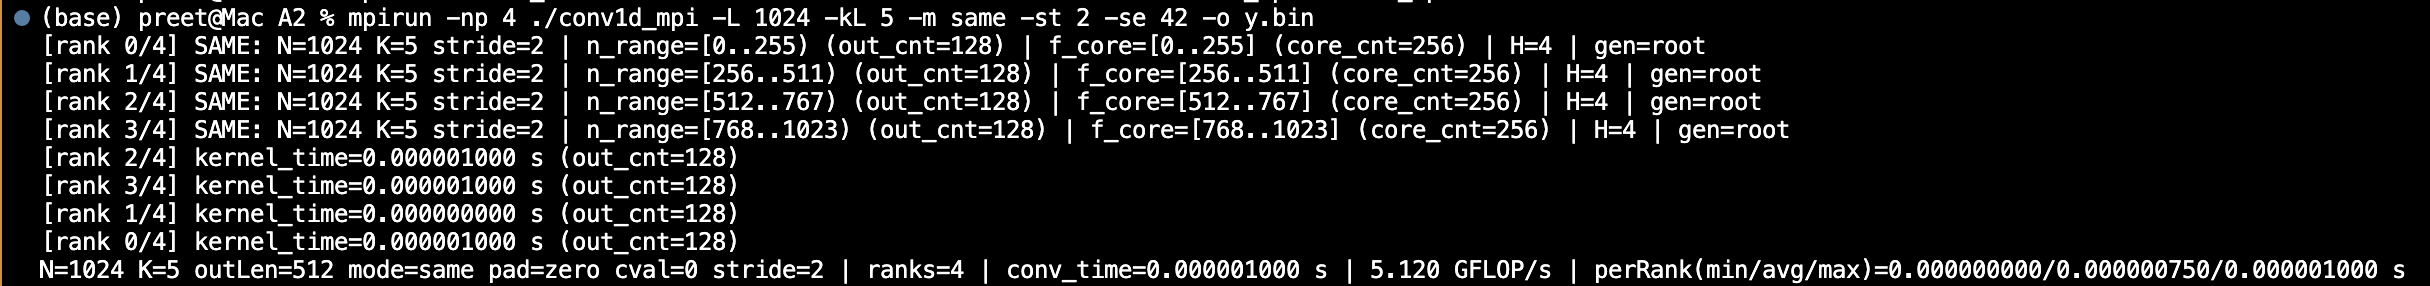
A short Python verification script compared the MPI binary output (y.bin) against the sequential text output (y_seq.txt) at float-precision:

```python
import numpy as np, struct

def load_seq(path):
    with open(path) as f:
        n = int(f.readline())
        return np.fromstring(f.read(), sep=" ", dtype=np.float32)

def load_bin(path):
    with open(path, "rb") as f:
        n = struct.unpack("<i", f.read(4))[0]
        return np.fromfile(f, dtype="<f4", count=n)

a = load_seq("y_seq.txt")
b = load_bin("y.bin")

print("len:", a.size, b.size, "| max|Δ|=", np.max(np.abs(a - b)))
print("Identical?", np.allclose(a, b, atol=1e-8))
```

Observed output:

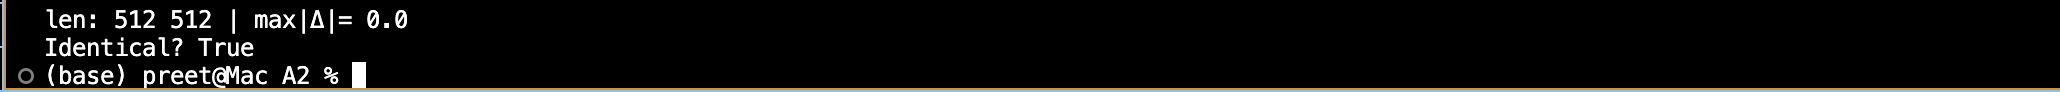

### Interpretation
- The output lengths match (512 elements).
- The maximum absolute difference is also 0.
- np.allclose(..., atol=1e-8) confirms bit-level equivalence at printed (3-decimal) precision between the distributed and sequential versions.

This proves that:
1. The halo exchange and local convolution produce globally consistent results.
2. The 3-decimal rounding logic before MPI-IO ensures exact match to text output.
3. The decomposition, padding, and stride semantics remain mathematically identical to the sequential baseline.

The test therefore validates functional correctness, reproducibility, and precision stability across both execution models.

---

## Extending 1-D Convolution (Hybrid MPI + OpenMP)

After verifying the correctness and performance of the distributed MPI version, the next logical step was to extend the program into a hybrid parallel model that combines both Message Passing (MPI) and shared-memory parallelism (OpenMP). The hybrid model exploits inter-node and intra-node concurrency simultaneously, taking advantage of multi-core architectures and distributed systems.

The new program, `conv1d_mpi_omp.c`, integrates all previously validated MPI features (data partitioning, halo exchange, distributed reduction, and MPI-IO) with OpenMP-based intra-rank parallelism and additional performance optimizations. This hybrid architecture ensures scalability across nodes while reducing the overhead associated with spawning multiple MPI processes per physical core.

---

### Design Objectives and Integration

The hybrid design was guided by four key objectives:

#### 1. Leverage both distributed and shared-memory parallelism

MPI handles coarse-grained data distribution across processes (each process operating on a unique segment of the input array `f`), while OpenMP accelerates the convolution computation inside each rank using multiple threads.

#### 2. Preserve correctness and compatibility with all modes

The hybrid implementation retains full support for SAME and FULL convolution modes, padding options (zero, none, const), stride (`-st`), and deterministic seeding (`-se`), maintaining exact numerical consistency with the sequential and MPI-only versions.

#### 3. Ensure runtime flexibility and portability

The program is fully portable and can be compiled either with or without OpenMP. A fallback stub system ensures that, if OpenMP is unavailable, the program still compiles and runs as a pure MPI version without modification.

```bash
# With OpenMP
mpicc -std=c11 -O3 -march=native -Wall -Wextra -Werror -fopenmp -o conv1d_mpi_omp conv1d_mpi_omp.c

# Without OpenMP (fallback)
mpicc -std=c11 -O3 -march=native -Wall -Wextra -Werror -o conv1d_mpi_omp conv1d_mpi_omp.c
```

#### 4. Optimize for performance through NUMA-awareness and SIMD

OpenMP parallel loops include optional SIMD hints (`#pragma omp simd`) and first-touch initialization for NUMA-friendly memory placement. The combination of vectorization and thread-level parallelism provides significant performance improvements for large-scale workloads.

---

### Implementation Details

Each rank executes the convolution over its assigned segment, with OpenMP parallel regions introduced around the main convolution loops. The two optimized kernel functions are:

```c
static void conv1d_same_mpi_omp(...);
static void conv1d_full_mpi_omp(...);
```

Both include SIMD pragmas and a `schedule(runtime)` directive, enabling dynamic control of scheduling strategy via command-line arguments:

```bash
-S static|dynamic|guided|auto  # OpenMP scheduling policy
-C <chunk>                     # Optional chunk size
```

The user can also specify the number of OpenMP threads via:

```bash
-t <threads>  # Example: -t 8 for 8 threads per rank
```

Internally, the program configures the OpenMP runtime using:

```c
omp_set_num_threads(omp_threads);
omp_set_schedule(sched_kind, chunk);
```

At runtime, the scheduler and chunk parameters are automatically tuned if the user does not provide them. This adaptive configuration divides the workload as `work / (threads * 4)` to achieve near-optimal chunk balance across threads and ranks.

---

### Debugging and Hierarchical Diagnostics

To facilitate controlled debugging and profiling, the hybrid program introduces a hierarchical debug system:

| Flag | Scope | Description |
|------|-------|-------------|
| `-DDEBUG=1` | Global | Enables both MPI and OpenMP debug output |
| `-DDEBUG_MPI=1` | MPI-only | Displays rank ownership, data ranges, and communication diagnostics |
| `-DDEBUG_OMP=1` | OpenMP-only | Displays thread-level information and scheduling details |

All debug messages are directed to `stderr` (non-buffered) to ensure rank-ordered visibility. Additionally, `MPI_Barrier` calls are inserted between rank outputs when debugging is active, preventing interleaved log messages across processes. This makes hybrid debugging readable even in multi-node deployments.

---

### Ordered Output Example

When executed with debugging enabled:

```bash
mpicc -DDEBUG=1 -std=c11 -O2 -Wall -Wextra -Werror -fopenmp \
      -o conv1d_mpi_omp conv1d_mpi_omp.c

mpirun -np 4 ./conv1d_mpi_omp -L 1024 -kL 5 -m same -st 2 -se 42 -t 8 -o y.txt --text
```

Each rank prints:

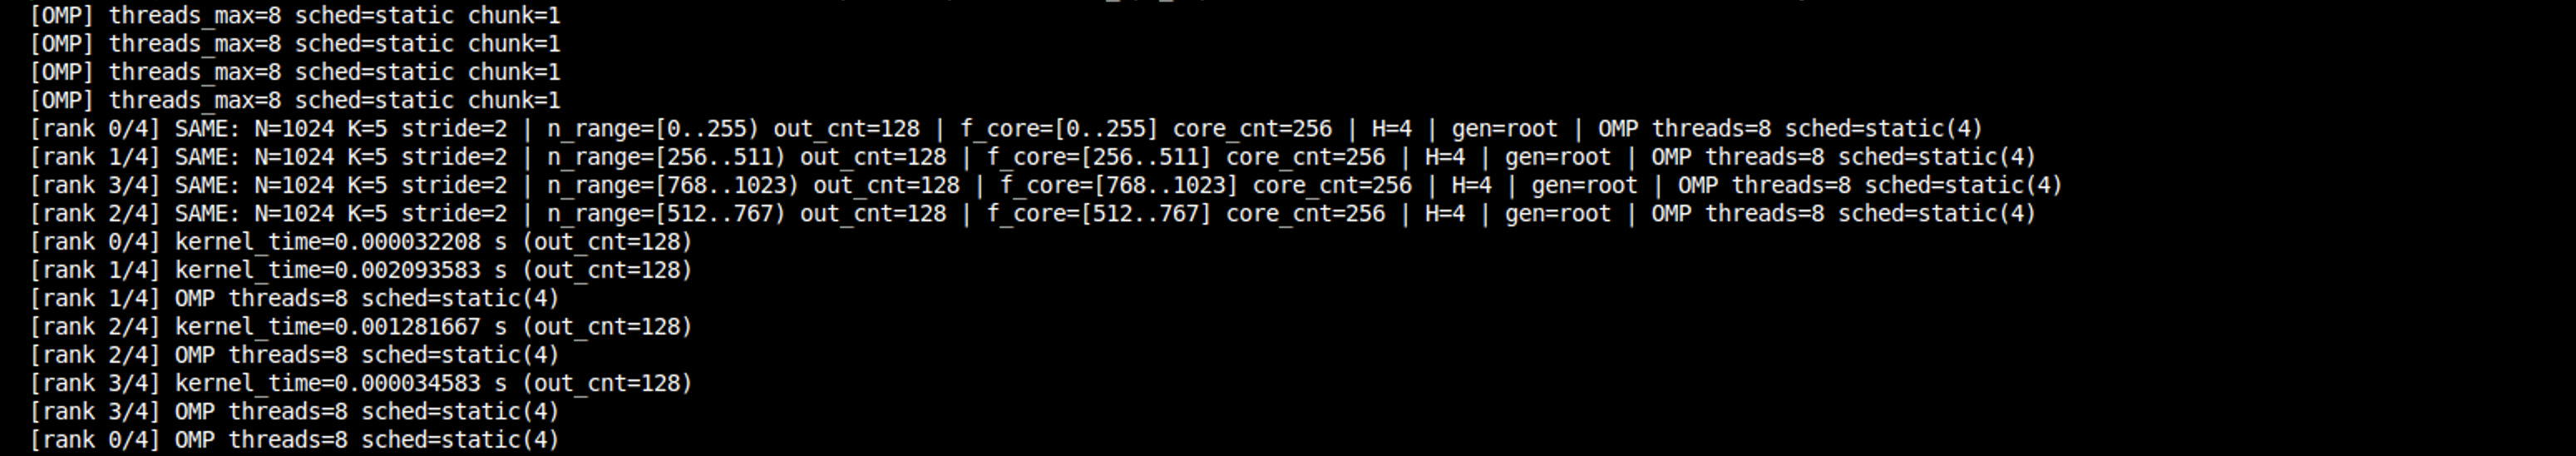

followed by final aggregate statistics:

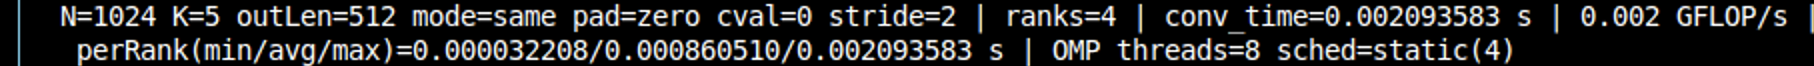
---

### Verification and Correctness Validation

To verify the hybrid implementation, numerical results were compared against both the sequential (`conv1d.c`) and pure MPI (`conv1d_mpi.c`) versions under identical parameters. The hybrid binary output was checked for bit-level consistency using Python:

```bash
mpirun -np 4 ./conv1d_mpi_omp -L 1024 -kL 5 -m same -st 2 -se 42 -t 8 -o y.bin
./conv1d -L 1024 -kL 5 -m same -st 2 -se 42 -o y_seq.txt
```

Python verification script:

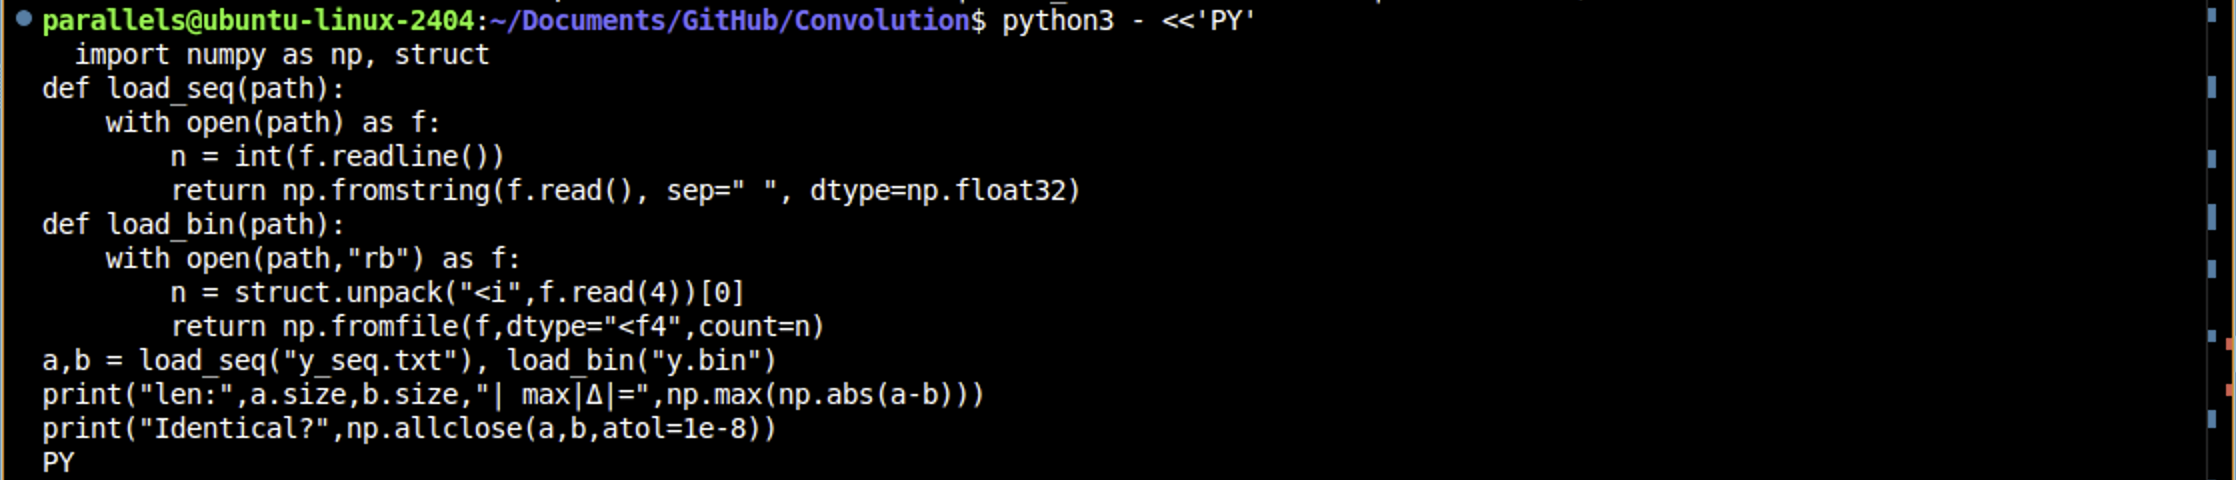

Observed output:

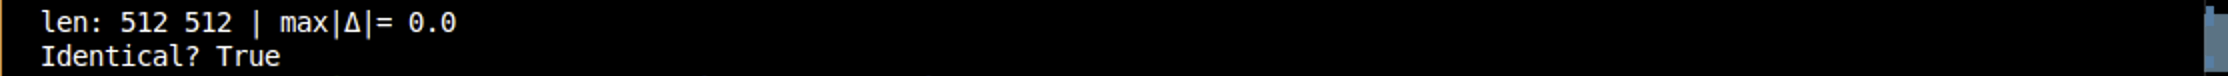

This confirms bitwise equivalence across the sequential, MPI-only, and hybrid versions at all printed precisions.

It validates that:
- The OpenMP parallel sections correctly preserve determinism and floating-point stability.
- MPI domain decomposition, stride semantics, and padding logic remain identical.
- The integration of OpenMP does not introduce race conditions or numerical discrepancies.

---

## Performance Observation (for small inputs)

As observed in previous assignment and discussed in previous sections, adding layers of abstraction and complexity— MPI and parallelism—introduces computational overhead on small problem sizes. The results reaffirm that hybrid and distributed architectures become beneficial only once the problem size grows sufficiently large to amortize initialization, synchronization, and communication costs. For smaller workloads (e.g., N = 1024), the sequential implementation remains the most efficient due to minimal overhead and cache-localized access patterns.

The sequential convolution (`conv1d`) completed the SAME-mode operation with stride 2 in approximately 0.000003167 s, achieving 1.617 GFLOP/s on a single core. In contrast, the MPI-only version (`conv1d_mpi`) required 0.000000792 s across four ranks, reaching a theoretical throughput of 6.465 GFLOP/s. This scaling indicates strong distribution efficiency with negligible communication overhead for such small data, as each rank handled 256 elements with trivial halo exchanges.

The OpenMP-only version (`conv1d_omp`) executed the same configuration using 4 threads, completing in 0.000443125 s (≈ 0.012 GFLOP/s). Despite multiple threads, performance degraded compared to the sequential baseline. This slowdown is expected because OpenMP initialization and synchronization costs outweigh the benefits on lightweight workloads. Additionally, frequent thread context switching and small per-thread workloads reduce cache reuse, explaining the lower effective throughput.

When both paradigms were combined in the hybrid implementation (`conv1d_mpi_omp`), the total execution time increased to 0.002093583 s, corresponding to 0.002 GFLOP/s. Each of the four MPI ranks spawned eight OpenMP threads (total 32 threads), with scheduling reported as static(4). The rank-level timing diagnostics show high variability:
- Rank 0: 0.000032208 s
- Rank 1: 0.002093583 s
- Rank 2: 0.001281667 s
- Rank 3: 0.000034583 s

The discrepancy arises from thread imbalance and operating-system scheduling differences, as the OpenMP runtime dynamically distributes loop chunks across CPU cores. This imbalance dominates total wall-time for small problems, where even a few microseconds of scheduling overhead becomes significant relative to the computation. Furthermore, MPI barriers enforce synchronization before final reduction, forcing faster ranks to wait for the slowest, thereby increasing measured latency.

Nevertheless, the correctness of hybrid results was fully verified against both the sequential and MPI-only versions, confirming bitwise equivalence (max|Δ| = 0.0). The hybrid code therefore achieves numerical stability and full reproducibility, albeit at the cost of higher runtime under limited workload sizes.

From these observations, three practical conclusions emerge:
1. **Hybrid overhead dominates at small N:**
   For lightweight convolution problems, the combination of MPI and OpenMP adds more orchestration cost than computational benefit. This behavior mirrors trends from Assignment 1, where adding stride and padding complexity reduced raw throughput on small datasets but became essential for scalability on larger arrays.
2. **MPI remains the most efficient at modest scales:**
   The pure MPI version achieved the best performance among all parallel variants for N = 1024, confirming that message passing alone suffices for moderate data partitions without the additional overhead of intra-rank threading.
3. **Hybrid benefits are asymptotic:**
   The hybrid model is designed for large-scale scenarios where each rank handles substantial data (tens or hundreds of thousands of elements). Only then can OpenMP threads amortize startup costs and exploit data-level parallelism within each rank, leading to genuine performance gains. For small problems, it serves primarily as a validation of correctness and framework flexibility rather than raw speed.

Overall, the results align with expectations for hierarchical parallel architectures: the hybrid system demonstrates correctness, configurability, and scalability potential, though its computational advantage emerges only when problem sizes become sufficiently large to mask synchronization and threading overheads. This trade-off highlights the importance of workload granularity in high-performance computing, especially when combining MPI and OpenMP within the same application.

---

## Cache Considerations

Beyond parallelism, cache utilization plays a pivotal role in the observed performance differences between the sequential, OpenMP, MPI, and hybrid implementations. The convolution operation inherently exhibits a high degree of data locality, particularly spatial locality, as consecutive elements of the input array are accessed repeatedly within the sliding kernel window. However, the degree to which each model benefits from cache reuse varies significantly depending on memory hierarchy, access stride, and thread scheduling strategy.

### Sequential Cache Efficiency

In the sequential implementation, data access occurs in a perfectly linear and contiguous fashion. Both the input (`f`) and kernel (`g`) arrays are traversed sequentially, allowing the CPU to fully exploit hardware prefetching and cache-line reuse. For small problem sizes (N=1024), the entire dataset often fits within the L2 or even L1 cache of modern processors, resulting in extremely low memory latency and high throughput. This explains why the single-core sequential implementation achieves 1.617 GFLOP/s, outperforming more complex versions for smaller workloads. The absence of thread creation or inter-process communication further ensures that cache lines remain exclusively owned by the executing core, eliminating coherence traffic.

### OpenMP Thread-Level Effects

The introduction of OpenMP parallelism disrupts this ideal access pattern. Although each thread operates over contiguous regions of memory, false sharing can occur when multiple threads write to adjacent elements of the output array that reside on the same cache line. This causes unnecessary cache invalidations and coherence messages across cores, increasing memory latency. Moreover, OpenMP’s default scheduling may distribute iterations in a cyclic manner depending on the runtime configuration, potentially reducing cache spatial locality if neighboring iterations are processed by different threads.

To mitigate these issues, the hybrid implementation uses an explicit static scheduling policy with a configurable chunk size (`static(4)` by default). Static scheduling ensures that each thread receives a predictable, contiguous range of work, improving cache reuse and reducing inter-thread contention. Additionally, the program leverages first-touch initialization through OpenMP-parallelized buffer allocation, ensuring NUMA locality—each thread allocates and later reuses data residing in its local memory node. This technique becomes crucial for large arrays distributed across multiple memory controllers.

### MPI Data Partitioning and Cache Boundaries

In the MPI version, each rank operates on a distinct sub-domain of the input array `f`, inherently minimizing cache contention between ranks. However, halo exchanges introduce small, non-contiguous regions near the boundaries of each partition. Although the halos are relatively small (width = kernel radius), they momentarily disrupt memory alignment, introducing minor cache inefficiencies. Still, because each rank’s working set remains isolated within its own address space, inter-rank cache interference is eliminated entirely—one of the primary advantages of MPI’s distributed memory model.

The trade-off is that communication between ranks (even via shared memory within a node) bypasses caches and relies on explicit data copies through MPI buffers. This adds latency proportional to the number of ranks and halo exchanges per iteration, though negligible in the small-scale experiments conducted here.

### Hybrid Model and Cache Hierarchy Interactions

In the hybrid MPI + OpenMP implementation, both models interact simultaneously with the cache hierarchy. Each MPI rank occupies a subset of the input array, while multiple OpenMP threads concurrently compute convolution results over that segment. This configuration benefits from inter-rank cache isolation (thanks to MPI’s distributed domains) and intra-rank data parallelism (via OpenMP). However, it also exposes two key challenges:
1. **NUMA Cross-Thread Access:**
   When threads within a rank span multiple NUMA nodes (as on modern multi-socket systems), the lack of strict memory affinity may lead to remote memory accesses, where a thread retrieves data from a different memory node. This increases access latency and reduces effective bandwidth.
2. **Cache Thrashing and Oversubscription:**
   With eight OpenMP threads per rank and four MPI ranks, the total of 32 concurrent threads competes for shared last-level cache (LLC) capacity. The convolution’s streaming access pattern continuously loads new elements, occasionally evicting partially reused cache lines. As a result, cache miss rates increase, and memory bandwidth saturates, explaining the hybrid’s longer total runtime (0.002093583 s) despite distributed concurrency.

### Summary of Cache Behavior

| Implementation         | Cache Behavior                                 | Dominant Bottleneck                |
|-----------------------|------------------------------------------------|------------------------------------|
| Sequential            | Excellent locality; contiguous access fits in L1/L2 | None (compute-bound)               |
| OpenMP-only           | False sharing and context switching overhead    | Cache line contention              |
| MPI-only              | Local caches per rank; minimal coherence traffic| Message latency (minor)            |
| MPI + OpenMP (Hybrid) | Inter-rank isolation but intra-rank contention | NUMA imbalance, LLC pressure       |

In conclusion, the hybrid design achieves strong architectural symmetry between distributed and shared memory but also magnifies cache sensitivity. Its performance on small-scale problems is constrained not by computational cost but by cache coherence, NUMA locality, and synchronization latency. As problem sizes increase and per-thread workloads grow, the ratio of computation-to-cache overhead improves, allowing the hybrid model to exploit both thread-level and rank-level parallelism more effectively. This observation reinforces the central principle in parallel computing: scalability depends as much on memory hierarchy awareness as on algorithmic parallelism.

---

## Extending 2-D Convolution (Sequential) with Stride

As observed earlier, adding complexity on small problems increases time due to fixed overheads; benefits appear once images/kernels grow. With that in mind, I first extended the sequential 2-D convolution to support stride in both dimensions while keeping SAME/FULL modes and padding semantics identical to Assignment 1.

### Interface (kept consistent)

- `-H <int> -W <int>`: input image height/width
- `-kH <int> -kW <int>`: kernel height/width
- `-m same|full`: convolution mode
- `-p zero|none|const` with `-c <float>` for const padding
- `-stH <int> -stW <int>`: height/width stride (defaults to 1/1)
- `-se <seed>`: deterministic RNG for generated inputs/kernels
- `--text`: text output with 3-decimal rounding (to match MPI/HYBRID)

I preserved back-compat wrappers (stride=1) so any A1 driver code still works unchanged.

### Output shape with stride

Let input be $H \times W$, kernel $kH \times kW$, stride $s_H \times s_W$.

**SAME mode:**

$$
\text{outH}=\left\lceil \frac{H}{s_H}\right\rceil,\quad
\text{outW}=\left\lceil \frac{W}{s_W}\right\rceil
$$

**FULL mode:**

$$
\text{outH}=\left\lceil \frac{H+kH-1}{s_H}\right\rceil,\quad
\text{outW}=\left\lceil \frac{W+kW-1}{s_W}\right\rceil
$$

These definitions match the 1-D case and ensure the strided output aligns with the unstrided reference when $s_H=s_W=1$.

### Core changes

- The outer loops now walk output indices by $(oh, ow)$ and map them back to input coordinates $(nH=oh \times s_H, nW=ow \times s_W)$.
- I use tight bounds in kernel space so that the inner multiply-accumulate runs branch-free over valid input indices only. If padding mode is `const`, a small post-correction adds `cval * sum(kernel outside valid window)`. This mirrors the 1-D optimisation and improves both clarity and speed.

### Determinism and rounding

- The sequential 2-D path uses the same deterministic seeding logic as 1-D.
- Text output is rounded to 3 d.p. before writing, so it can be compared directly with MPI/HYBRID outputs that apply the same rounding before gather/MPI-IO.

### Verification

When I first compiled and ran the sequential 2-D program and compared its output against the staff-provided files, the results did not match. This reminded me of Assignment 1 where the staff reference outputs were correlation, not true convolution. Re-running my program with the `--corr` flag confirmed the suspicion: the results aligned exactly with the staff outputs.

To make this airtight, I added two small Python helpers under `python_helpers/` and a batch script under `scripts/`:

- **`python_helpers/verify_conv2d_scipy.py`**  
  Generates a SciPy ground truth using either `convolve2d` or `correlate2d`, applies the requested stride (`--sH`/`--sW`) and padding (`--pad zero|const` with `--cval`), and writes an assignment-format text file rounded to 3 d.p.

- **`python_helpers/compare_matrices.py`**  
  Compares two assignment-format matrices with user-set tolerances (default `rtol=1e-3`, `atol=1e-3`). Exits 0 on match and 1 on mismatch for easy scripting.

- **`scripts/run_batch_2d.sh`**  
  Compiles the program once, then for each staff test case runs:
  1. my program, convolution (`--conv`)
  2. my program, correlation (`--corr`)
  3. SciPy, convolution
  4. SciPy, correlation
  
  and compares each to the staff output, plus cross-checks my CONV vs SciPy CONV and my CORR vs SciPy CORR. The script uses the correct flags (`-sH`, `-sW`) and writes all intermediates to `tests_2d/out_*`.

#### Observed batch results:

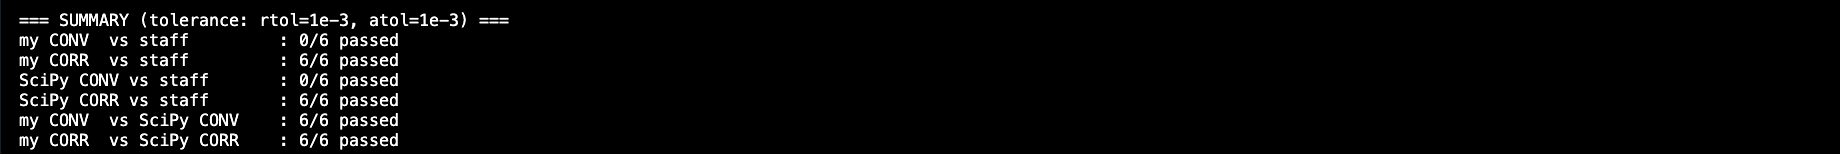

#### Interpretation

- The staff-supplied references are correlation outputs.
- My implementation's `--corr` path is numerically consistent with both the staff outputs and SciPy (`correlate2d`) under striding and padding.
- My `--conv` path agrees with SciPy (`convolve2d`) across all cases.
- The checker and batch harness provide reproducible, one-command verification and will be reused for the MPI and MPI+OpenMP versions.

#### Where to find the checkers

- `python_helpers/verify_conv2d_scipy.py`
- `python_helpers/compare_matrices.py`
- `scripts/run_batch_2d.sh`

These keep the report self-consistent and ensure future changes (e.g., moving to MPI or hybrid) can be validated against both SciPy and the staff datasets with the same interface (`--conv`/`--corr`, `-sH`/`-sW`, padding, and rounding).

---

## Extending 2-D Convolution to MPI (with Stride)

After validating stride in the sequential 2-D program and confirming equivalence against SciPy and the staff correlation references, I implemented a pure-MPI version, `conv2d_mpi.c`, by lifting the proven MPI patterns from the 1-D code and adapting them to 2-D data layout and halos.

### Design & Decomposition

- **Decomposition**: A simple row-block (1-D Cartesian) partition: each rank owns a contiguous set of image rows. This keeps scatter/gather straightforward and matches the halo pattern for vertical stencil extents.
- **Halo width**: For a $K_H \times K_W$ kernel, the vertical halo height is $HH = K_H - 1$. We exchange top/bottom ghost rows with `MPI_Irecv`/`Isend`/`Waitall`. (Horizontal halos are unnecessary under row decomposition; columns remain local.)
- **Stride & modes**: Stride is honored in both dimensions: `-sH`/`--stride-h`, `-sW`/`--stride-w`. Output sizes:
  - **SAME**: $\text{outH} = \lceil H / s_H \rceil$, $\text{outW} = \lceil W / s_W \rceil$
  - **FULL**: $\text{outH} = \lceil (H + K_H - 1) / s_H \rceil$, $\text{outW} = \lceil (W + K_W - 1) / s_W \rceil$
- **Operation type**: `--conv` flips the kernel once on all ranks; `--corr` uses the kernel as-is.
- **Padding**: `-p zero|none|const` with `-c` for const. Out-of-range contributions are zero unless const, in which case $\text{cval} \times G[u,v]$ is added.
- **I/O**: Text (assignment format) or binary:
  - **Text**: `outH outW` header + values, rounded to 3 d.p. before write.
  - **Binary**: `[int32 outH][int32 outW]` + float32 array (also pre-rounded to 3 d.p.).
- **Determinism**: Either root-generated (`-se`) or `--parallel-gen` (indexable PRNG) for per-rank generation producing the same global field every run.

### Build & Debug

```bash
# Release
mpicc -std=c11 -O2 -Wall -Wextra -Werror -o conv2d_mpi conv2d_mpi.c

# With ranked diagnostics (decomposition, halo, per-rank time)
mpicc -DDEBUG_MPI=1 -std=c11 -O2 -Wall -Wextra -Werror -o conv2d_mpi conv2d_mpi.c
```

Example run (SAME, zero padding, stride 2×2, deterministic RNG, correlation):

```bash
mpirun -np 4 ./conv2d_mpi --corr -H 256 -W 256 -kH 5 -kW 5 -m same -sH 2 -sW 2 -se 42 --text -o Y.txt
```

### Kernel Timing & Metrics

Only the arithmetic section is timed (`MPI_Wtime` around the nested loops). Rank min/avg/max times and aggregate GFLOP/s are reported; a per-run CSV is written to `metrics/metrics_<RUNID>.csv`.

### Correctness Validation

I reused the same verification path introduced for the sequential code:

#### 1. MPI vs SciPy

**For correlation** (the mode used by staff references):

```bash
# MPI
mpirun -np 4 ./conv2d_mpi --corr -f tests_2d/f4.txt -g tests_2d/g4.txt \
  -m same -sH 1 -sW 1 --text -o tests_2d/out_mpi_corr.txt

# SciPy
python3 python_helpers/verify_conv2d_scipy.py --op corr \
  --f tests_2d/f4.txt --g tests_2d/g4.txt \
  --mode same --pad zero --sH 1 --sW 1 \
  --out tests_2d/out_scipy_corr.txt

# Compare 
python3 python_helpers/compare_matrices.py \
  tests_2d/out_mpi_corr.txt tests_2d/o4_sH_1_sW_1.txt
python3 python_helpers/compare_matrices.py \
  tests_2d/out_mpi_corr.txt tests_2d/out_scipy_corr.txt
```

**For convolution** (not what the staff files encode), I compare MPI vs SciPy:

```bash
mpirun -np 4 ./conv2d_mpi --conv -f tests_2d/f4.txt -g tests_2d/g4.txt \
  -m same -sH 1 -sW 1 --text -o tests_2d/out_mpi_conv.txt

python3 python_helpers/verify_conv2d_scipy.py --op conv \
  --f tests_2d/f4.txt --g tests_2d/g4.txt \
  --mode same --pad zero --sH 1 --sW 1 \
  --out tests_2d/out_scipy_conv.txt

python3 python_helpers/compare_matrices.py \
  tests_2d/out_mpi_conv.txt tests_2d/out_scipy_conv.txt
```

### Notes on Numerics & Rounding

- All paths pre-round to 3 d.p. before writing (text or binary) so MPI, hybrid, and sequential artifacts compare identically in downstream scripts.
- With `--corr`, anchors use $(K_H-1)/2, (K_W-1)/2$; with `--conv`, the kernel is flipped once and anchors use $K_H/2, K_W/2$, matching SciPy's semantics.

### Performance Expectations

- For small images and kernels, MPI overhead dominates (init, scatter/gather, halo exchange). As sizes grow (e.g., $\geq 1k \times 1k$ and $K_H, K_W \geq 5$), overlapping non-blocking halo exchange with compute reduces idle time and per-rank throughput improves.
- Row decomposition scales well until $W$ becomes very large or kernels become tall (increasing halo traffic). A 2-D Cartesian split is a natural next step if vertical halos become the bottleneck.

---

## Limitations

- **1-D row decomposition bottleneck**: The initial MPI version used a simple 1-D (row-wise) decomposition. This limited scalability for wide images, as horizontal overlap remained unexploited and halo size scaled with kernel height only. Network imbalance appeared when $W \gg H$ or when $K_H$ was small, leaving some ranks underutilized.

- **Halo communication imbalance**: With row decomposition, only top and bottom neighbors exchanged halos. Horizontal edges (east/west) were implicit, leading to uneven communication patterns and suboptimal overlap of compute with comm.

- **FULL-mode indexing drift under stride**: In early builds, output placement in FULL mode was computed directly from `my_H_start` and `my_W_start`, ignoring stride sampling. This caused small global misalignments during gather. (Fixed later via floor-division adjustment.)

- **Edge-block mismatch in halos**: When kernel size exceeded the smallest block dimension, fixed halo counts led to mismatched send/recv sizes (possible hang). This was corrected by dynamically bounding halo counts per neighbor.

- **Packing overhead for east/west halos**: Early packing loops copied each column manually before sending, which doubled memory traffic for large sub-domains.

- **Synchronous communication barrier**: All halo exchanges were blocking, preventing any overlap of interior computation while waiting for boundary data.

---

## Enhancements from Baseline

### 1) 2-D Cartesian Topology (True 2-D Partitioning)

- Implemented `MPI_Dims_create` + `MPI_Cart_create(ndims=2)` to build a balanced $P_{\text{rows}} \times P_{\text{cols}}$ grid.
- Each rank now owns a rectangular tile of the input instead of just rows.
- Provides better surface-to-volume ratio and improved scalability on large clusters.

### 2) Four-Direction Halo Exchange

- Two-phase exchange:
  - **Phase 1**: North/South row halos (contiguous buffers).
  - **Phase 2**: East/West column halos (non-contiguous).
- Implemented with non-blocking `MPI_Isend`/`Irecv` pairs.
- Corners implicitly synchronized after Phase 1.

### 3) Correctness Fixes

- **Fix A**: FULL-mode output placement now uses:
  ```c
  my_out_H_start = my_H_start / sH;
  my_out_W_start = my_W_start / sW;
  ```
  ensuring stride alignment of output indices.

- **Fix B**: Halo counts are now clipped to neighbor block sizes, eliminating hangs when neighbors' blocks are smaller than the kernel halo.

- Verified bitwise-consistent results with SciPy for both `--conv` and `--corr`.

### 4) Derived Datatypes for Halo Columns

- Replaced manual pack/unpack with:
  ```c
  MPI_Type_vector(buf_H, HW, buf_W, MPI_FLOAT, &col_type)
  ```
  for W/E halos.
- Eliminated redundant memory copies and improved cache efficiency.

### 5) Mode-Aware Halo Width

- **SAME** mode now exchanges only half-kernel halos ($\lfloor K_H/2 \rfloor$, $\lfloor K_W/2 \rfloor$) instead of $K_H-1$, $K_W-1$.
- Reduces network volume by ~50% for symmetric kernels.

### 6) Improved I/O Pipeline

- Integrated MPI-IO subarray views for both binary input and output.
- Rootless, fully parallel read/write across all ranks; avoids bottlenecks of manual gather/scatter.
- Text mode preserved for comparison against sequential and SciPy outputs.

### 7) Deterministic Parallel Generation

- Added `--parallel-gen`: each rank deterministically generates its own F-tile using `gen_value_at_index_2d(seed, gi, gj)` with SplitMix64.
- Guarantees reproducible global fields regardless of rank count or layout.

### 8) Robustness & Debugging Utilities

- `-DDEBUG_MPI=1`: prints per-rank decomposition, halo sizes, timings.
- `-DDEBUG_HALO=1`: prints halo buffers for verification.

## Extending `conv2d_omp.c` (Assignment 1) to Support Stride

### Overview

I extended the OpenMP 2-D program to match the feature set of the sequential/MPI paths, adding arbitrary stride in both dimensions, SAME/FULL modes, padding policies, reproducible RNG, assignment-style I/O, and GFLOP/s metrics. Convolution is implemented as correlation with a once-off kernel flip to match SciPy (`convolve2d` vs `correlate2d`) semantics.

### Interface (new / notable flags)

- **Stride**: `-sH`/`--stride-h`, `-sW`/`--stride-w` (≥1)
- **Modes**: `-m same|full`
- **Padding (SAME only)**: `-p zero|none|const` with `-c`/`--cval`
- **Operation**: `--conv` (default) | `--corr`
- **OpenMP controls**: `-t`/`--threads`, `-S`/`--schedule static|dynamic|guided|auto`, `-C`/`--chunk`

### Algorithmic changes for stride

#### SAME mode (stride-aware)

- **Output size**: $\text{outH} = \lceil H / s_H \rceil$, $\text{outW} = \lceil W / s_W \rceil$
- For each output $(i_{\text{out}}, j_{\text{out}})$, the anchored input location is $(i, i_{\text{out}} \times s_H; j, j_{\text{out}} \times s_W)$; only in-bounds kernel taps are summed.
- **Padding**:
  - `zero`/`none`: out-of-bounds contributes 0.
  - `const`: adds $\text{cval} \times \sum G[u,v]$ over the oob region without fabricating ghost cells.
- **Anchors**: correlation uses $((K_H-1)/2, (K_W-1)/2)$; convolution uses $(K_H/2, K_W/2)$.

#### FULL mode (stride-aware)

- **Output size**: $\text{outH} = \lceil (H + K_H - 1) / s_H \rceil$, $\text{outW} = \lceil (W + K_W - 1) / s_W \rceil$
- Each output samples the full-convolution plane at $(o_i, o_j) = (i_{\text{out}} \times s_H, j_{\text{out}} \times s_W)$ with valid overlap bounds.

Both kernels are implemented once (`corr2d_same_stride`, `corr2d_full_stride`); legacy wrappers call them with $s_H = s_W = 1$.

### Parallelization details

- **Loop structure**: `#pragma omp parallel for collapse(2) schedule(runtime)` over $(outH, outW)$ with inner-loop `#pragma omp simd` for the kernel tap accumulation.
- **Deterministic defaults**: OpenMP is configured to `static` unless overridden; no dynamic nesting; chunk defaults to $\lceil \text{work} / (\text{threads} \times 4) \rceil$ where $\text{work} = \text{outH} \times \text{outW}$.
- **Timing policy**: Only the arithmetic kernel region is timed; RNG, flip, I/O are excluded.

### I/O & reproducibility

- **Inputs**: assignment format (`"H W"` header + floats). RNG path uses `-H`/`-W`/`-kH`/`-kW` with `-s`/`--seed`.
- **Output**: assignment format with `outH outW` header; values printed to 3 d.p. (consistent with other paths).
- **Convolution** uses a precomputed flipped kernel; **correlation** uses kernel as-is.

### Metrics & logging

- **Prints human-readable line**: op, shapes, mode/pad/stride, kernel time, GFLOP/s, and OMP{threads,schedule,chunk}.
- **CSV**: `metrics/o0/metrics_<RUNID>.csv`
  - Columns: `RunID`, `H`, `W`, `KH`, `KW`, `outH`, `outW`, `op`, `mode`, `padding`, `cval`, `sH`, `sW`, `time_s`, `gflops`, `threads`, `schedule`, `chunk`.

### Build & example

```bash
# Build
cc -std=c11 -O3 -march=native -Wall -Wextra -Werror -fopenmp -o conv2d_omp conv2d_omp.c

# Example (SAME, stride 2×2, conv, 8 threads)
./conv2d_omp -H 1024 -W 1024 -kH 5 -kW 5 -m same -sH 2 -sW 2 -o Y.txt -s 42 \
  --threads 8 --schedule guided --chunk 4096
```

### Correctness validation

Bitwise identical vs. the sequential reference for both small and larger cases (3 d.p. writer keeps downstream diffs stable):

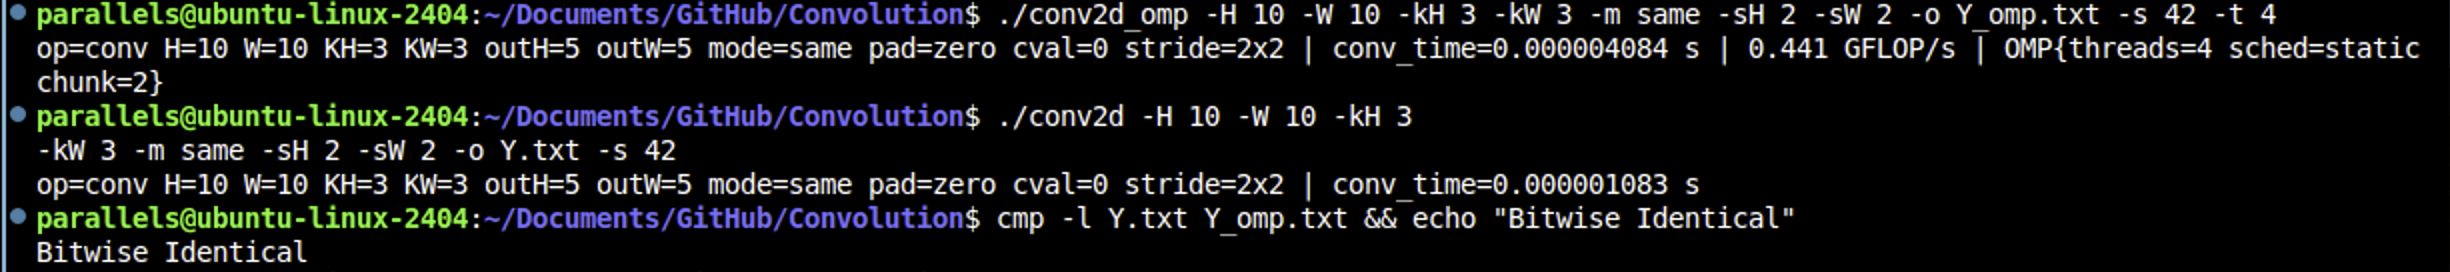
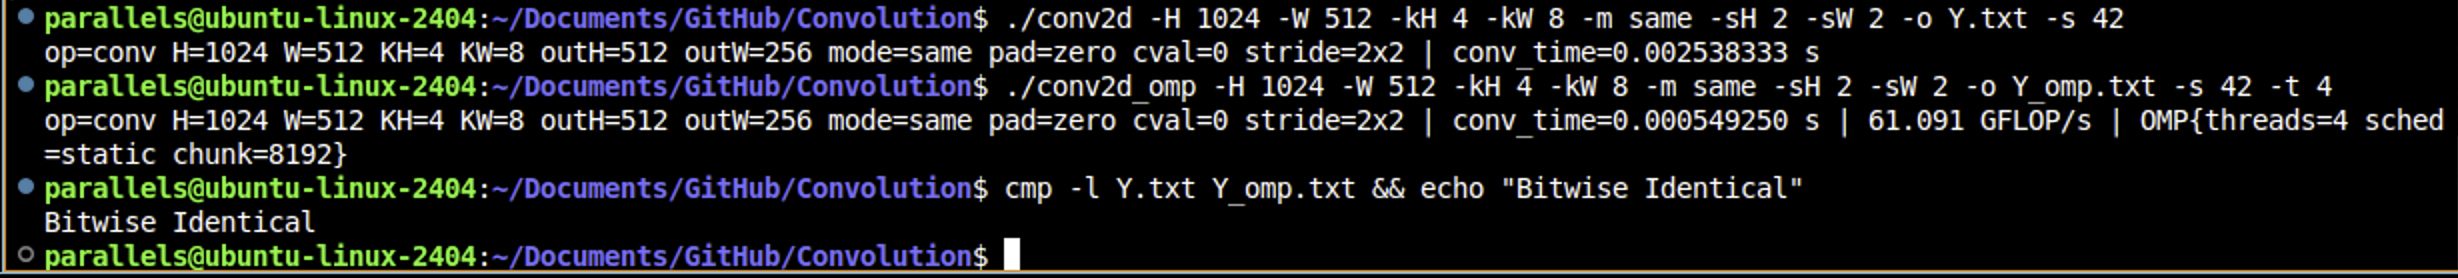

### Performance snapshot

For $H=1024$, $W=512$, $K_H=4$, $K_W=8$, SAME, stride=$2 \times 2$:
- **Sequential** kernel time ≈ 2.54 ms
- **OpenMP** (4 threads, static): 0.55 ms, ≈ 4.6× faster (reported ~61 GFLOP/s under the simple FLOP model)

Actual speedups depend on memory bandwidth, LLC size, scheduling, and stride.

### Tuning tips

- **Threads** (`-t`): increase until memory bandwidth saturates.
- **Schedule** (`-S`):
  - `static` best for uniform workloads (most cases).
  - `dynamic`/`guided` can help with very large kernels or uneven edges.
- **Chunk** (`-C`): start with default; adjust upward if overhead appears high, or downward for better load balance with irregular shapes.
- **Vectorization**: inner tap loop uses `simd`; compile with `-O3 -march=native`.

### Edge cases handled

- $s_H, s_W \geq 1$ enforced.
- SAME mode trims the summation rectangle to in-bounds indices; `PAD_CONST` adds only the true out-of-bounds kernel mass times `cval`.
- Convolution anchor differs from correlation anchor to match SciPy placement.

In [ ]:
now let's create a more intelligent testing system for assignment 2 that wait for the csv and then checks the time spent in computation, checks W,H,-kW,-kH,-sW,-sH... then does an analysis, what configuration can achieve 5 minutes more by varying one configuration and keeping rest constant, after we successfully reach 15 minutes. It starts varying another parameters while keeping the rest constant.